# Image and Video Processing Lab 5

### Import Libraries

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def show_image(title, img, cmap='gray'):
    plt.imshow(img, cmap=cmap)
    plt.title(title)
    plt.axis('off')

### Load Image

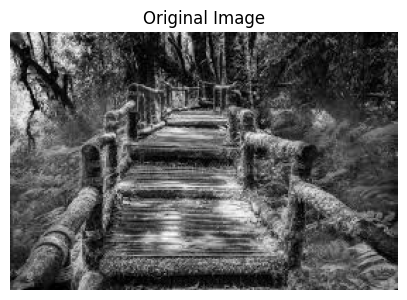

In [3]:
img = cv2.imread('image.png', cv2.IMREAD_GRAYSCALE)

if img is None:
    raise ValueError("Image not loaded. Check file path.")

plt.figure(figsize=(5,5))
show_image("Original Image", img)

### Experiment #1: Gaussian Filtering

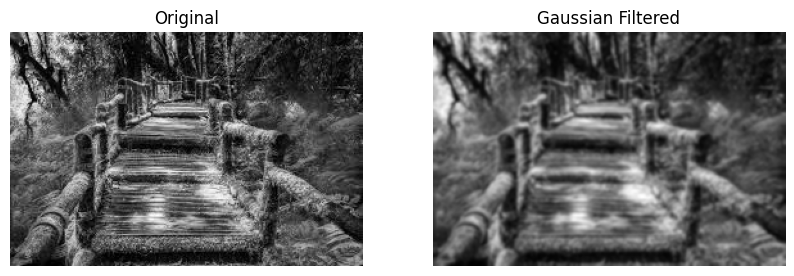

In [4]:
gaussian_img = cv2.GaussianBlur(img, (5,5), 0)

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
show_image("Original", img)

plt.subplot(1,2,2)
show_image("Gaussian Filtered", gaussian_img)

Gaussian filtering smooths the image using a Gaussian kernel.
It reduces noise and detail by applying weighted averaging.

### Experiment #2: Frequency Domain Filtering

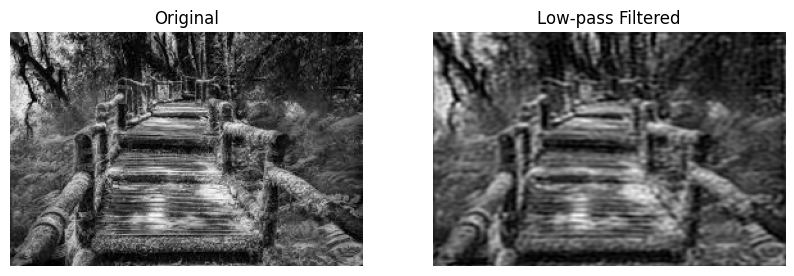

In [5]:
# DFT
dft = np.fft.fft2(img)
dft_shift = np.fft.fftshift(dft)

rows, cols = img.shape
crow, ccol = rows//2 , cols//2

# Create mask (low-pass filter)
mask = np.zeros((rows, cols), np.uint8)
r = 50  # radius
center = (crow, ccol)

for i in range(rows):
    for j in range(cols):
        if (i - crow)**2 + (j - ccol)**2 <= r*r:
            mask[i,j] = 1

# Apply mask
filtered = dft_shift * mask

# Inverse DFT
f_ishift = np.fft.ifftshift(filtered)
img_back = np.fft.ifft2(f_ishift)
img_back = np.abs(img_back)

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
show_image("Original", img)

plt.subplot(1,2,2)
show_image("Low-pass Filtered", img_back)

Frequency domain filtering involves transforming the image using DFT,
modifying frequency components, and reconstructing the image.

### Experiment #3: Median Filter

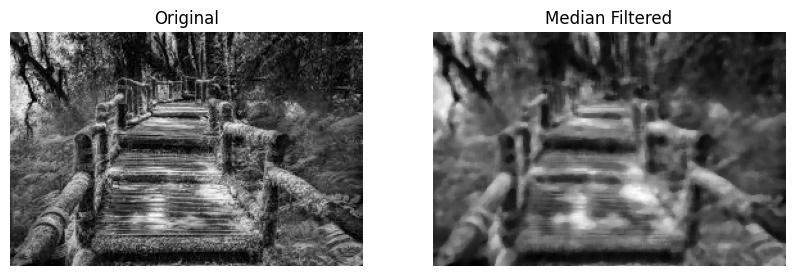

In [6]:
median_img = cv2.medianBlur(img, 5)

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
show_image("Original", img)

plt.subplot(1,2,2)
show_image("Median Filtered", median_img)

Median filtering replaces each pixel with the median of its neighborhood.
It is highly effective for removing salt-and-pepper noise.

### Experiment #4: Forward and Inverse DFT

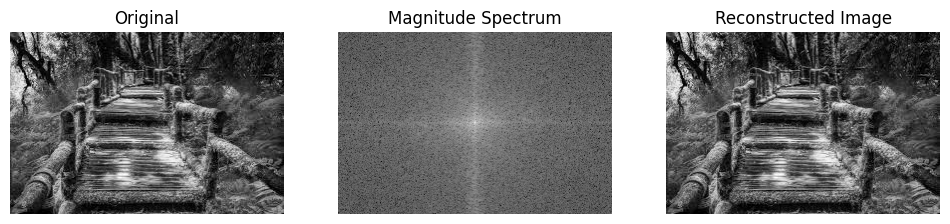

In [7]:
# Forward DFT
dft = np.fft.fft2(img)
dft_shift = np.fft.fftshift(dft)

# Magnitude spectrum
magnitude = 20 * np.log(np.abs(dft_shift) + 1)

# Inverse DFT
idft_shift = np.fft.ifftshift(dft_shift)
img_reconstructed = np.fft.ifft2(idft_shift)
img_reconstructed = np.abs(img_reconstructed)

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
show_image("Original", img)

plt.subplot(1,3,2)
show_image("Magnitude Spectrum", magnitude)

plt.subplot(1,3,3)
show_image("Reconstructed Image", img_reconstructed)

DFT converts spatial domain data into frequency domain.
Inverse DFT reconstructs the original image from frequency data.